<a href="https://colab.research.google.com/github/Ramez147/Ramez147/blob/main/_DS5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df1 = pd.read_excel("/content/drive/MyDrive/Transaktionsdaten/Luechow_2025Q1.xlsx")
df2 = pd.read_excel("/content/drive/MyDrive/Transaktionsdaten/Itzehoe_2025Q1.xlsx")
df3 = pd.read_excel("/content/drive/MyDrive/Transaktionsdaten/Pritzwalk_2025Q2.xlsx")
df4 = pd.read_excel("/content/drive/MyDrive/Transaktionsdaten/Hagenow_2025Q2.xlsx")

In [ ]:
MostSoldWarengruppe = df1.groupby('Warengruppe')['Gesamtpreis'].sum().sort_values(ascending=False)
display(MostSoldWarengruppe.head(10))

,Gesamtpreis
Warengruppe,
Diesel,1136878.55
Super,247558.50
Tabakwaren,242090.27
Super E10,94011.01
Fastfood erm. Ust,48215.02
CNG,40410.77
Autowäsche,26455.25
ADBLUE,25631.06
Kaffee/Heißgetränke,18866.80


In [ ]:
WetterInLuechow = pd.read_csv("/content/drive/MyDrive/Luechow_WetterDaten.csv")
WetterInLuechow

,date,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
0,2025-01-01 00:00:00,7.0,3.7,9.1,3.4,0,NaN,30.6,67.0,1007.5,0
1,2025-01-02 00:00:00,3.4,0.9,6.3,0.6,0,NaN,14.4,49.0,1007.8,218
2,2025-01-03 00:00:00,1.1,-0.7,3.1,1.0,0,NaN,18.0,61.2,1011.4,25
3,2025-01-04 00:00:00,0.1,-1.5,1.3,0.0,0,NaN,10.8,33.5,1017.1,41
4,2025-01-05 00:00:00,-0.3,-1.3,1.1,14.0,0,NaN,10.8,39.2,1002.6,1
...,...,...,...,...,...,...,...,...,...,...,...
86,2025-03-28 00:00:00,7.7,-2.6,17.6,0.0,0,NaN,5.4,24.8,1012.8,430
87,2025-03-29 00:00:00,8.5,0.8,14.8,0.0,0,NaN,10.8,33.8,1015.1,194
88,2025-03-30 00:00:00,7.0,0.5,12.2,5.6,0,NaN,15.8,50.4,1010.3,37
89,2025-03-31 00:00:00,7.0,-0.2,10.2,0.0,0,NaN,13.0,36.0,1022.4,92


In [ ]:
df1['timestamp'] = pd.to_datetime(df1['timestamp'])
df1['date'] = df1['timestamp'].dt.date


täglicheUmsatzLuechow = df1.groupby('date')['Gesamtpreis'].sum().reset_index()
täglicheUmsatzLuechow.rename(columns={'Gesamtpreis': 'GesamtUmsatz'}, inplace=True)

display(täglicheUmsatzLuechow.head())

,date,GesamtUmsatz
0,2025-01-01,7944.26
1,2025-01-02,13868.88
2,2025-01-03,18915.98
3,2025-01-04,10005.69
4,2025-01-05,7694.88


In [ ]:
WetterInLuechow['date'] = pd.to_datetime(WetterInLuechow['date']).dt.date
display(WetterInLuechow.head())

,date,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
0,2025-01-01,7.0,3.7,9.1,3.4,0,NaN,30.6,67.0,1007.5,0
1,2025-01-02,3.4,0.9,6.3,0.6,0,NaN,14.4,49.0,1007.8,218
2,2025-01-03,1.1,-0.7,3.1,1.0,0,NaN,18.0,61.2,1011.4,25
3,2025-01-04,0.1,-1.5,1.3,0.0,0,NaN,10.8,33.5,1017.1,41
4,2025-01-05,-0.3,-1.3,1.1,14.0,0,NaN,10.8,39.2,1002.6,1


In [ ]:
merged_df = pd.merge(täglicheUmsatzLuechow, WetterInLuechow, on='date', how='inner')

correlation_df = merged_df[['GesamtUmsatz', 'tavg', 'prcp', 'wspd', 'tsun']]

correlation_matrix = correlation_df.corr()

display(correlation_matrix)

,GesamtUmsatz,tavg,prcp,wspd,tsun
GesamtUmsatz,1.000000,-0.008880,-0.135912,-0.130697,0.004599
tavg,-0.008880,1.000000,0.069826,0.166027,0.055949
prcp,-0.135912,0.069826,1.000000,0.167317,-0.358752
wspd,-0.130697,0.166027,0.167317,1.000000,-0.312621
tsun,0.004599,0.055949,-0.358752,-0.312621,1.000000


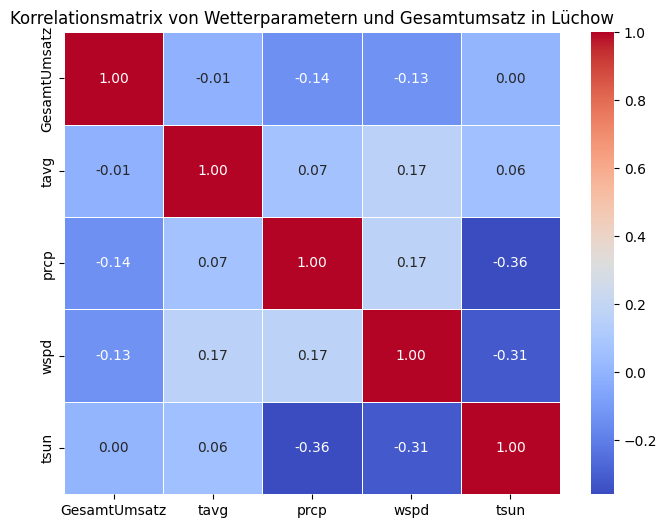

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Korrelationsmatrix von Wetterparametern und Gesamtumsatz in Lüchow')
plt.show()

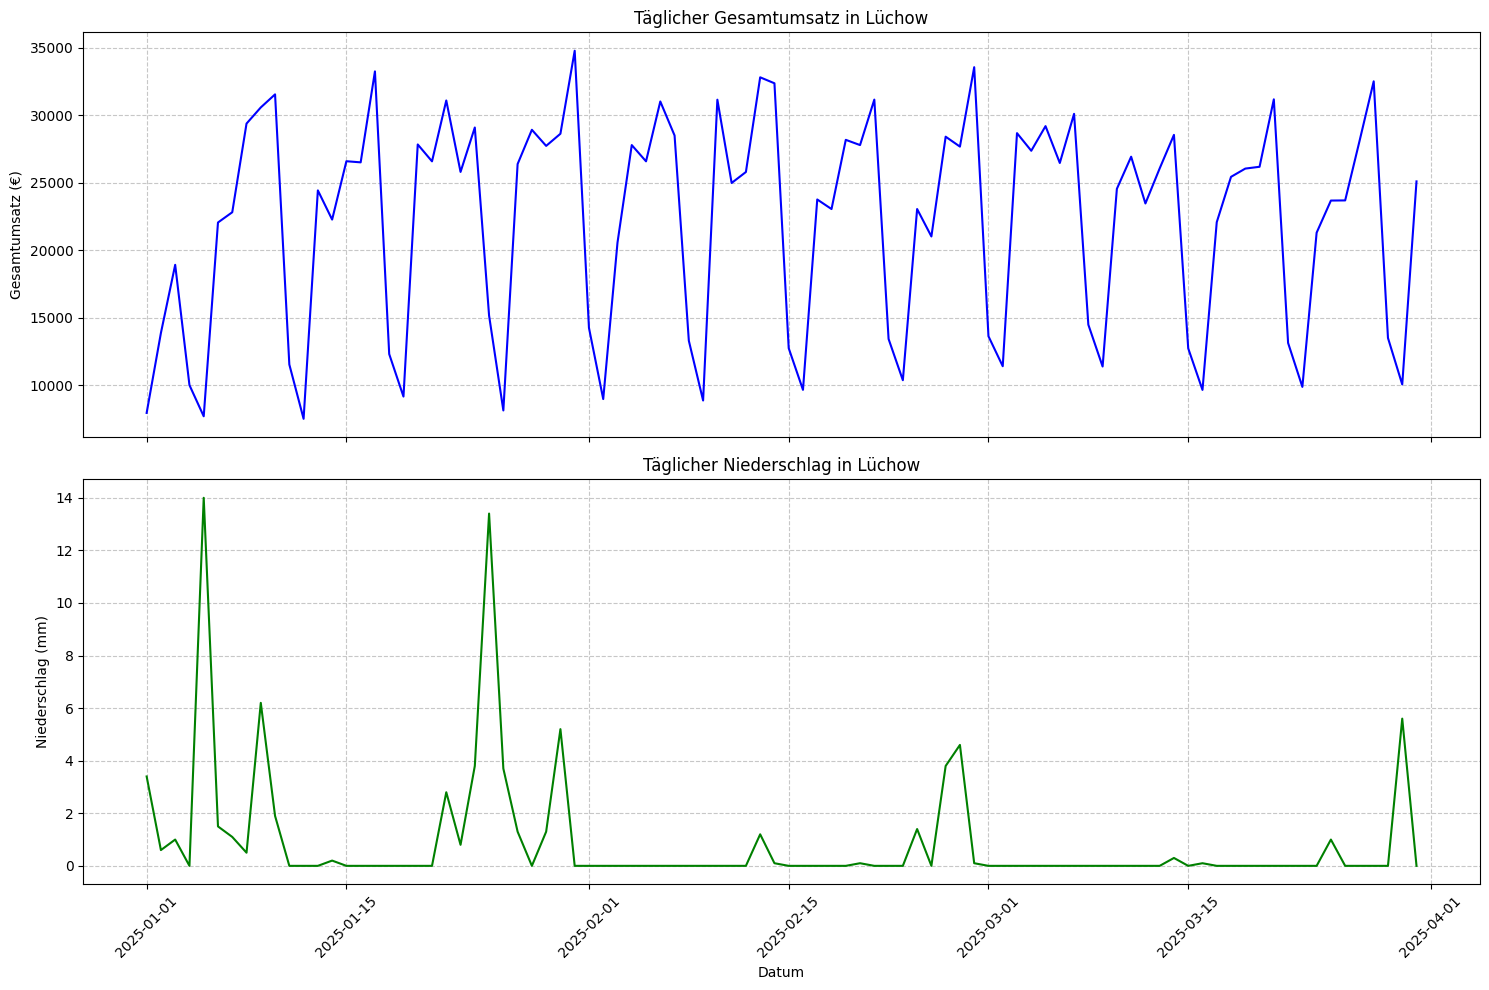

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

sns.lineplot(ax=axes[0], x='date', y='GesamtUmsatz', data=merged_df, color='blue')
axes[0].set_title('Täglicher Gesamtumsatz in Lüchow')
axes[0].set_ylabel('Gesamtumsatz (€)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot Täglicher Niederschlag
sns.lineplot(ax=axes[1], x='date', y='prcp', data=merged_df, color='green')
axes[1].set_title('Täglicher Niederschlag in Lüchow')
axes[1].set_xlabel('Datum')
axes[1].set_ylabel('Niederschlag (mm)')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Tagestyp,Durchschnittlicher Gesamtumsatz (€)
0,Regentage,23332.734828
1,Nicht-Regentage,21622.750820


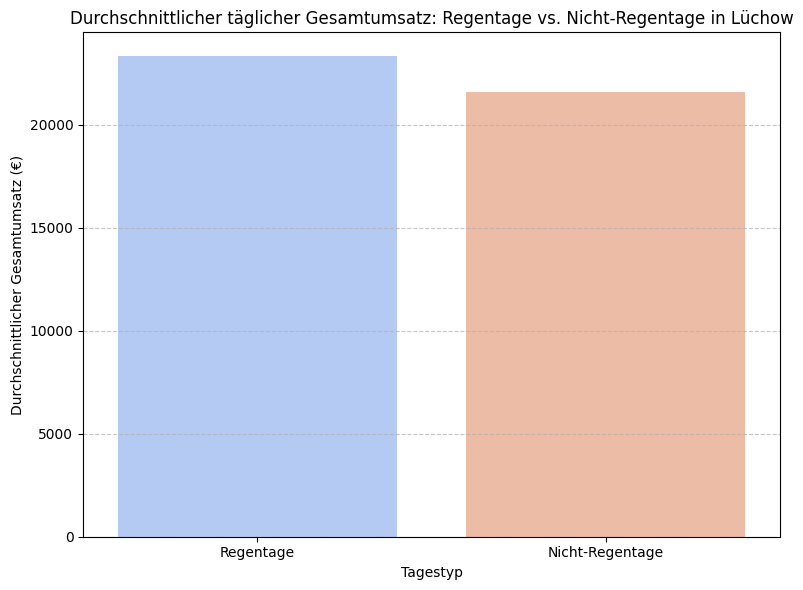

In [ ]:
# Filtere nach Regentagen (prcp > 0)
rainy_days_df = merged_df[merged_df['prcp'] > 0].copy()

# Filtere nach Tagen ohne Regen (prcp == 0)
non_rainy_days_df = merged_df[merged_df['prcp'] == 0].copy()

# Berechne den durchschnittlichen Umsatz für Regentage und Nicht-Regentage
average_turnover_rainy = rainy_days_df['GesamtUmsatz'].mean()
average_turnover_non_rainy = non_rainy_days_df['GesamtUmsatz'].mean()

# Erstelle ein DataFrame für den Vergleich
comparison_turnover = pd.DataFrame({
    'Tagestyp': ['Regentage', 'Nicht-Regentage'],
    'Durchschnittlicher Gesamtumsatz (€)': [average_turnover_rainy, average_turnover_non_rainy]
})

display(comparison_turnover)

# Visualisiere den Vergleich
plt.figure(figsize=(8, 6))
sns.barplot(x='Tagestyp', y='Durchschnittlicher Gesamtumsatz (€)', hue='Tagestyp', data=comparison_turnover, palette='coolwarm', legend=False)
plt.title('Durchschnittlicher täglicher Gesamtumsatz: Regentage vs. Nicht-Regentage in Lüchow')
plt.xlabel('Tagestyp')
plt.ylabel('Durchschnittlicher Gesamtumsatz (€)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()